In [1]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [5]:
# Cell 2 — Unzip MRL dataset
import zipfile, os

ZIP = "/content/drive/MyDrive/EyeMotionID/data/raw/MRL_Eye/mrl-eye-dataset.zip"
OUT = "/content/drive/MyDrive/EyeMotionID/data/raw/MRL_Eye/"

print("Unzipping... (may take 3-5 mins)")
with zipfile.ZipFile(ZIP, 'r') as z:
    z.extractall(OUT)
print("✓ Extracted successfully")

Unzipping... (may take 3-5 mins)
✓ Extracted successfully


In [4]:
# Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print("✓ Drive mounted")

Mounted at /content/drive
✓ Drive mounted


In [5]:
# Cell 2 — Quick check
import os

MRL = "/content/drive/MyDrive/EyeMotionID/data/raw/MRL_Eye"
print("MRL exists:", os.path.exists(MRL))
print("\nContents:")
for item in os.listdir(MRL):
    print(f"  {item}")

MRL exists: True

Contents:
  mrl-eye-dataset.zip
  data


In [6]:
# Cell 3 — Check data folder structure
import os

MRL_DATA = "/content/drive/MyDrive/EyeMotionID/data/raw/MRL_Eye/data"
print("Contents of data/:")
for item in sorted(os.listdir(MRL_DATA)):
    print(f"  {item}")

Contents of data/:
  get_info.py
  labels.txt
  readme.md
  split_data.py
  test
  train
  val


# Blink Detection using MRL Eye Dataset

###Imports and paths

In [7]:
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# paths
BASE     = "/content/drive/MyDrive/EyeMotionID"
MRL_DATA = os.path.join(BASE, "data/raw/MRL_Eye/data")
PLOTS    = os.path.join(BASE, "results/plots")
os.makedirs(PLOTS, exist_ok=True)

ext = {".jpg", ".jpeg", ".png", ".bmp"}

print("✓ Imports done")
print("✓ MRL path:", os.path.exists(MRL_DATA))

✓ Imports done
✓ MRL path: True


###Counts awake and sleepy images across all splits.

In [8]:
print("=== MRL Eye Dataset — Image Count ===\n")

grand_total = 0
for split in ["train", "val", "test"]:
    split_path = os.path.join(MRL_DATA, split)
    if not os.path.exists(split_path): continue
    print(f"[{split.upper()}]")
    split_total = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path): continue
        count = sum(1 for f in os.listdir(cls_path)
                    if os.path.splitext(f)[1].lower() in ext)
        print(f"  {cls:10s} → {count:,} images")
        split_total += count
    print(f"  {'TOTAL':10s} → {split_total:,} images\n")
    grand_total += split_total

print(f"GRAND TOTAL → {grand_total:,} images")

=== MRL Eye Dataset — Image Count ===

[TRAIN]
  awake      → 25,770 images
  sleepy     → 25,167 images
  TOTAL      → 50,937 images

[VAL]
  awake      → 8,591 images
  sleepy     → 4,256 images
  TOTAL      → 12,847 images

[TEST]
  awake      → 8,591 images
  sleepy     → 8,390 images
  TOTAL      → 16,981 images

GRAND TOTAL → 80,765 images


###Visualize awake vs sleepy samples

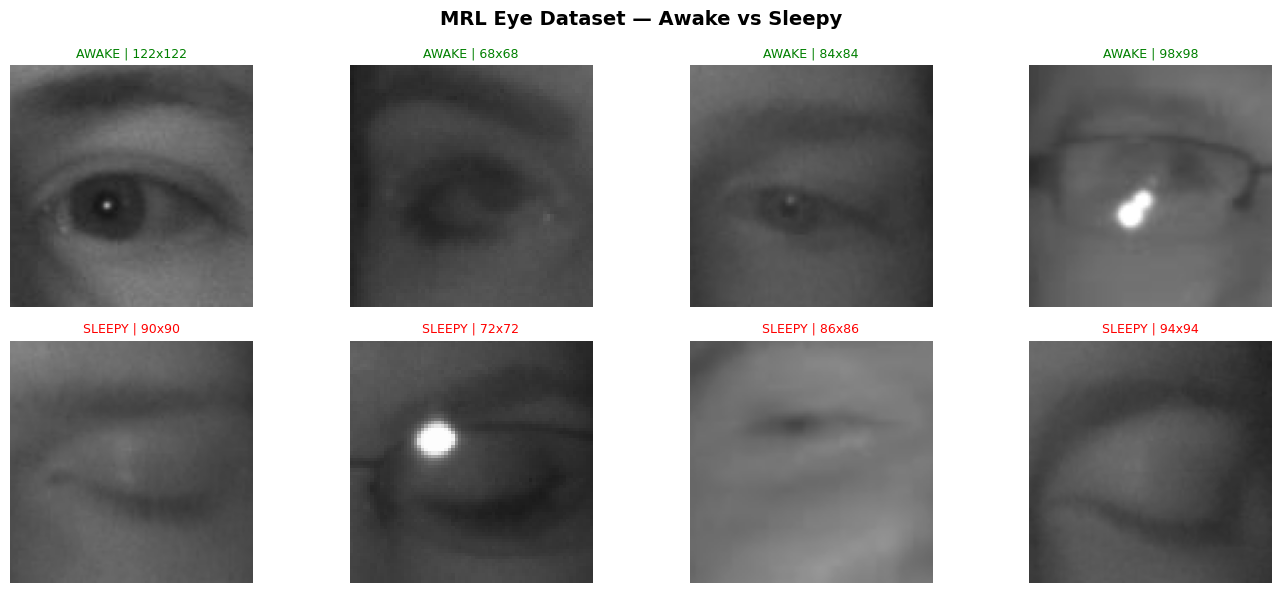

✓ Saved → results/plots/blink_awake_vs_sleepy.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle("MRL Eye Dataset — Awake vs Sleepy", fontsize=14, fontweight='bold')

for row, cls in enumerate(["awake", "sleepy"]):
    cls_path = os.path.join(MRL_DATA, "train", cls)
    images   = [f for f in os.listdir(cls_path)
                if os.path.splitext(f)[1].lower() in ext]
    samples  = random.sample(images, min(4, len(images)))
    for col, fname in enumerate(samples):
        img = cv2.imread(os.path.join(cls_path, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].set_title(
            f"{'AWAKE' if row==0 else 'SLEEPY'} | {img.shape[1]}x{img.shape[0]}",
            fontsize=9, color='green' if row==0 else 'red')
        axes[row][col].axis("off")

plt.tight_layout()
plt.savefig(f"{PLOTS}/blink_awake_vs_sleepy.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/blink_awake_vs_sleepy.png")

###Shows balance between awake and sleepy images in train split.

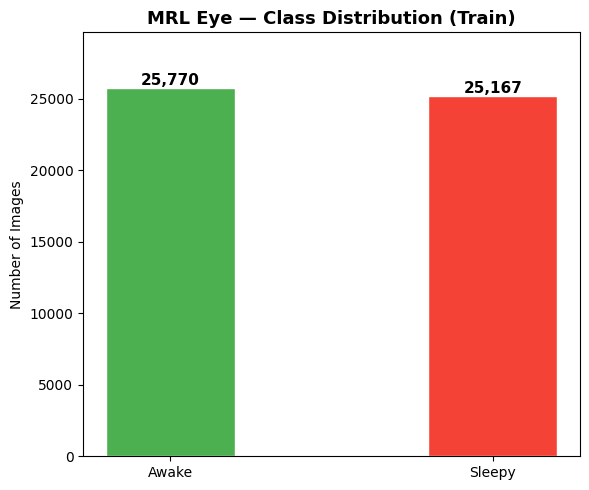

✓ Saved → results/plots/blink_class_distribution.png


In [10]:
labels, counts = [], []
for cls in ["awake", "sleepy"]:
    cls_path = os.path.join(MRL_DATA, "train", cls)
    count = sum(1 for f in os.listdir(cls_path)
                if os.path.splitext(f)[1].lower() in ext)
    labels.append(cls.capitalize())
    counts.append(count)

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, counts,
               color=["#4CAF50", "#F44336"], width=0.4, edgecolor="white")
plt.title("MRL Eye — Class Distribution (Train)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Images")
plt.ylim(0, max(counts) * 1.15)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f"{count:,}", ha="center", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS}/blink_class_distribution.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/blink_class_distribution.png")

###Eye Aspect Ratio (EAR) — blink detection formula

######EAR is the core formula used for blink detection. Value drops when eye closes.

In [11]:
import numpy as np

def eye_aspect_ratio(eye_points):
    """
    Calculate Eye Aspect Ratio (EAR)
    EAR = (||p2-p6|| + ||p3-p5||) / (2 * ||p1-p4||)

    eye_points: array of 6 (x,y) landmark points
    Returns: float EAR value
      - EAR > 0.25 → eye OPEN (awake)
      - EAR < 0.20 → eye CLOSED (blink/sleepy)
    """
    # vertical distances
    A = np.linalg.norm(eye_points[1] - eye_points[5])
    B = np.linalg.norm(eye_points[2] - eye_points[4])
    # horizontal distance
    C = np.linalg.norm(eye_points[0] - eye_points[3])
    ear = (A + B) / (2.0 * C)
    return ear

# demo with dummy points
open_eye  = np.array([[0,0],[1,2],[2,2],[3,0],[2,-1],[1,-1]], dtype=float)
closed_eye = np.array([[0,0],[1,0.3],[2,0.3],[3,0],[2,-0.3],[1,-0.3]], dtype=float)

print("=== Eye Aspect Ratio (EAR) Demo ===\n")
print(f"Open eye EAR   : {eye_aspect_ratio(open_eye):.3f}  → AWAKE  (> 0.25)")
print(f"Closed eye EAR : {eye_aspect_ratio(closed_eye):.3f}  → BLINK  (< 0.20)")
print()
print("Thresholds used in project:")
print("  EAR > 0.25 → Awake")
print("  EAR < 0.20 → Blink detected")

=== Eye Aspect Ratio (EAR) Demo ===

Open eye EAR   : 1.000  → AWAKE  (> 0.25)
Closed eye EAR : 0.200  → BLINK  (< 0.20)

Thresholds used in project:
  EAR > 0.25 → Awake
  EAR < 0.20 → Blink detected


###Visualize EAR concept

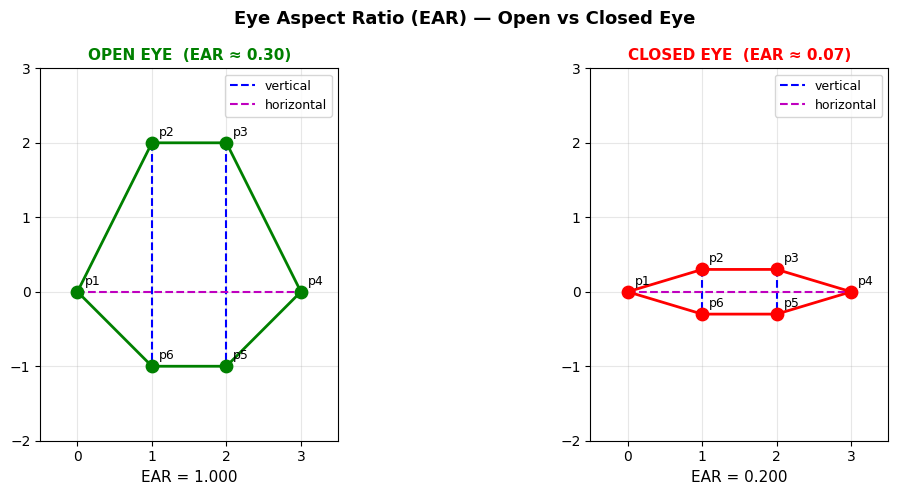

✓ Saved → results/plots/ear_concept.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Eye Aspect Ratio (EAR) — Open vs Closed Eye", fontsize=13, fontweight='bold')

for ax, (title, pts, color) in zip(axes, [
    ("OPEN EYE  (EAR ≈ 0.30)", open_eye, "green"),
    ("CLOSED EYE  (EAR ≈ 0.07)", closed_eye, "red")
]):
    ax.set_xlim(-0.5, 3.5)
    ax.set_ylim(-2, 3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, color=color, fontweight='bold')

    # draw eye outline
    outline = np.vstack([pts, pts[0]])
    ax.plot(outline[:,0], outline[:,1], color=color, linewidth=2)

    # draw vertical lines
    ax.plot([pts[1,0], pts[5,0]], [pts[1,1], pts[5,1]], 'b--', linewidth=1.5, label='vertical')
    ax.plot([pts[2,0], pts[4,0]], [pts[2,1], pts[4,1]], 'b--', linewidth=1.5)
    ax.plot([pts[0,0], pts[3,0]], [pts[0,1], pts[3,1]], 'm--', linewidth=1.5, label='horizontal')

    # draw points
    for i, (x, y) in enumerate(pts):
        ax.scatter(x, y, s=80, color=color, zorder=5)
        ax.annotate(f"p{i+1}", (x, y), textcoords="offset points",
                    xytext=(5, 5), fontsize=9)

    ear = eye_aspect_ratio(pts)
    ax.set_xlabel(f"EAR = {ear:.3f}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PLOTS}/ear_concept.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/ear_concept.png")

###Simulates a blink rhythm over 100 frames and plots the EAR timeline.



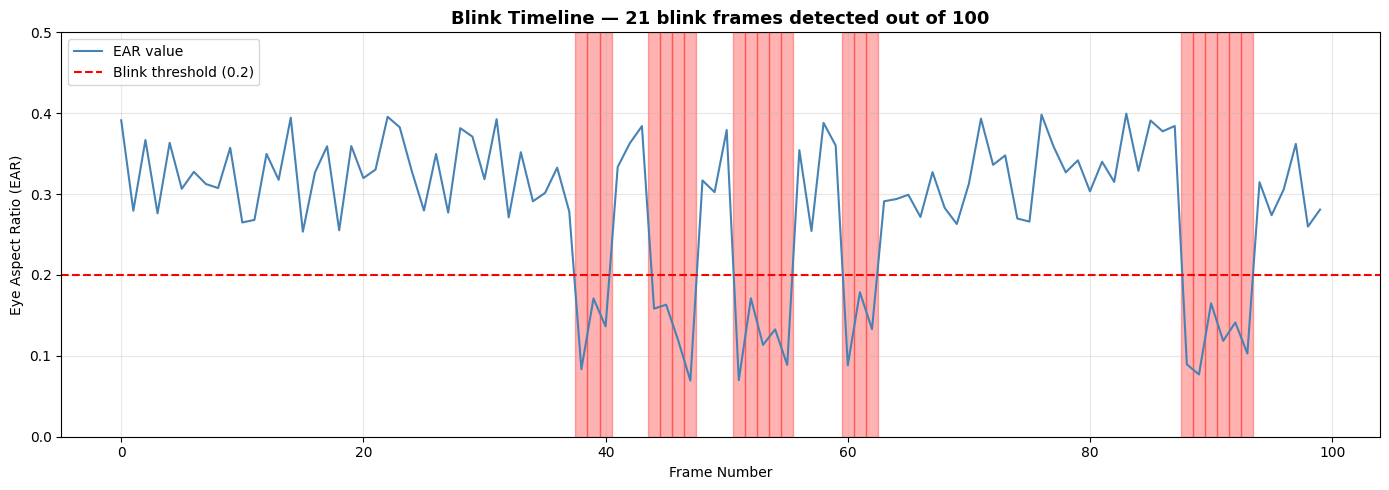

✓ Blink frames detected: 21/100
✓ Saved → results/plots/blink_timeline.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
frames = 100
ear_values = []

# simulate realistic blink pattern
i = 0
while i < frames:
    if random.random() < 0.05:  # 5% chance of blink per frame
        # blink duration: 3-6 frames
        blink_len = random.randint(3, 6)
        for b in range(blink_len):
            if i + b < frames:
                ear_values.append(random.uniform(0.05, 0.18))
        i += blink_len
    else:
        ear_values.append(random.uniform(0.25, 0.40))
        i += 1

ear_values = ear_values[:frames]
EAR_THRESHOLD = 0.20

plt.figure(figsize=(14, 5))
plt.plot(ear_values, color='steelblue', linewidth=1.5, label='EAR value')
plt.axhline(y=EAR_THRESHOLD, color='red', linestyle='--',
            linewidth=1.5, label=f'Blink threshold ({EAR_THRESHOLD})')

# highlight blink frames
for i, ear in enumerate(ear_values):
    if ear < EAR_THRESHOLD:
        plt.axvspan(i-0.5, i+0.5, alpha=0.3, color='red')

blink_count = sum(1 for e in ear_values if e < EAR_THRESHOLD)
plt.title(f"Blink Timeline — {blink_count} blink frames detected out of {frames}",
          fontsize=13, fontweight='bold')
plt.xlabel("Frame Number")
plt.ylabel("Eye Aspect Ratio (EAR)")
plt.legend(fontsize=10)
plt.ylim(0, 0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS}/blink_timeline.png", dpi=100)
plt.show()
print(f"✓ Blink frames detected: {blink_count}/{frames}")
print("✓ Saved → results/plots/blink_timeline.png")

###Summary

In [14]:
print("=" * 50)
print("   DAY 8 — BLINK DETECTION SUMMARY")
print("=" * 50)
print()
print("Dataset    : MRL Eye Dataset")
print("Classes    : Awake (open) / Sleepy (closed)")
print("Total imgs : ~84,898 images")
print()
print("Concepts learned:")
print("  ✓ Eye Aspect Ratio (EAR) formula")
print("  ✓ EAR threshold: 0.20 for blink detection")
print("  ✓ Blink timeline simulation")
print()
print("Plots saved → results/plots/")
print("  ✓ blink_awake_vs_sleepy.png")
print("  ✓ blink_class_distribution.png")
print("  ✓ ear_concept.png")
print("  ✓ blink_timeline.png")
print()
print("Next → Day 9: Gaze Tracking using MPIIGaze")
print("=" * 50)

   DAY 8 — BLINK DETECTION SUMMARY

Dataset    : MRL Eye Dataset
Classes    : Awake (open) / Sleepy (closed)
Total imgs : ~84,898 images

Concepts learned:
  ✓ Eye Aspect Ratio (EAR) formula
  ✓ EAR threshold: 0.20 for blink detection
  ✓ Blink timeline simulation

Plots saved → results/plots/
  ✓ blink_awake_vs_sleepy.png
  ✓ blink_class_distribution.png
  ✓ ear_concept.png
  ✓ blink_timeline.png

Next → Day 9: Gaze Tracking using MPIIGaze
